<a href="https://colab.research.google.com/github/aleakucing/Pembelajaran-Memsin/blob/main/JS05/JS05_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#1 buat dataset dummy
import numpy as np
from sklearn.datasets import make_classification

X,y = make_classification(n_samples=30, n_features=2, n_classes=2, n_informative=2, n_redundant=0, n_repeated=0, shuffle=False)

X = np.absolute(X)
X = np.round(X, 2) * 100

X = X.astype(int)

print(X)
print(y)

[[130 163]
 [101  98]
 [103 138]
 [115  95]
 [114 101]
 [ 90  93]
 [139 118]
 [ 92  82]
 [166  44]
 [138  11]
 [136  17]
 [ 61 293]
 [147  16]
 [114 111]
 [ 99 170]
 [134 101]
 [133  47]
 [117  73]
 [ 90 120]
 [126  54]
 [105  85]
 [ 95 107]
 [ 86 124]
 [124  64]
 [ 39  82]
 [ 80  74]
 [125 146]
 [154 126]
 [ 16  77]
 [127  73]]
[0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 1 1 1 1 1 1 1]


In [2]:
#2 membuat data frame
import pandas as pd

y_new = y.reshape(len(y), 1)

data = np.concatenate((X, y_new), axis=1)

nama_kolom = ['Fitur 1', 'Fitur 2', 'Label']

df = pd.DataFrame(data, columns=nama_kolom)

df.head()

,Fitur 1,Fitur 2,Label
0,130,163,0
1,101,98,0
2,103,138,0
3,115,95,0
4,114,101,0


In [3]:
#3 labelling
labels = {
    1 : 'Kelas A',
    0 : 'Kelas B'
}

df_label = df.copy()

df_label['Label'] = df_label['Label'].map(labels)

df_label.head()

,Fitur 1,Fitur 2,Label
0,130,163,Kelas B
1,101,98,Kelas B
2,103,138,Kelas B
3,115,95,Kelas B
4,114,101,Kelas B


/tmp/ipykernel_1572/126554725.py:10: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  class_a = gb.get_group('Kelas A')
/tmp/ipykernel_1572/126554725.py:11: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  class_b = gb.get_group('Kelas B')


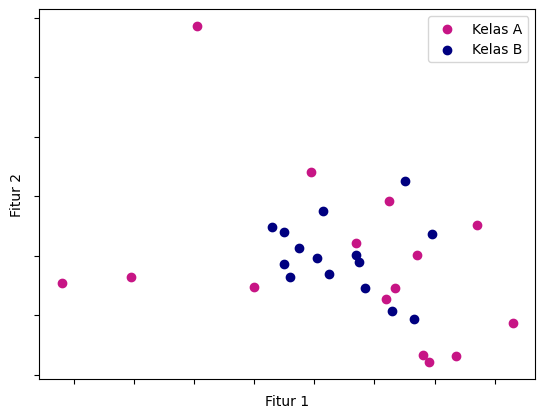

In [5]:
#4 visualisasi data
import matplotlib.pyplot as plt

colors = {
    'class_a': 'MediumVioletRed',
    'class_b': 'Navy'
}

gb = df_label.groupby(['Label'])
class_a = gb.get_group('Kelas A')
class_b = gb.get_group('Kelas B')

plt.scatter(x=class_a['Fitur 1'], y=class_a['Fitur 2'], c=colors['class_a'])
plt.scatter(x=class_b['Fitur 1'], y=class_b['Fitur 2'], c=colors['class_b'])
plt.xlabel('Fitur 1')
plt.ylabel('Fitur 2')
plt.legend(['Kelas A', 'Kelas B'])
plt.gca().axes.xaxis.set_ticklabels([])
plt.gca().axes.yaxis.set_ticklabels([])
plt.show()

In [6]:
#5 model multinominal naive bayes
from sklearn.naive_bayes import MultinomialNB # class untuk model MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score # evaluasi model berdasarkan akurasi

mnb = MultinomialNB()
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=30)

mnb.fit(X_train, y_train)

y_train_pred = mnb.predict(X_train)

acc_train = accuracy_score(y_train, y_train_pred)

y_test_pred = mnb.predict(X_test)

acc_test = accuracy_score(y_test, y_test_pred)

print(f'Hasil akurasi data train: {acc_train}')
print(f'Hasil akurasi data test: {acc_test}')

Hasil akurasi data train: 0.6666666666666666
Hasil akurasi data test: 0.2222222222222222


In [7]:
#6 model gaussian naive bayes
from sklearn.naive_bayes import GaussianNB # class untuk model GaussianNB

gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_train_pred_gnb = gnb.predict(X_train)
acc_train_gnb = accuracy_score(y_train, y_train_pred_gnb)
y_test_pred_gnb = gnb.predict(X_test)

acc_test_gnb = accuracy_score(y_test, y_test_pred_gnb)

print(f'Hasil akurasi data train (Gaussian): {acc_train_gnb}')
print(f'Hasil akurasi data test (Gaussian): {acc_test_gnb}')

Hasil akurasi data train (Gaussian): 0.8095238095238095
Hasil akurasi data test (Gaussian): 0.5555555555555556
